In [60]:
import json
import os
import pandas as pd
from pathlib import Path
import evaluate
from asr_thesis_project.utils.latex_metrics import LatexInContextMetrics
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import bootstrap
import numpy as np

In [61]:
results_directory = os.path.join("..", "results")
metrics = LatexInContextMetrics()

/home/alex/Desktop/programming/python/asr-thesis-project/.venv/lib/python3.13/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/alex/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package wordnet to /home/alex/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/alex/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/alex/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Multimodal RAG

In [62]:
multimodal_rag_directory = os.path.join(results_directory, "multimodal_rag")
multimodal_rag_predictions = pd.read_json(os.path.join(multimodal_rag_directory, "predictions.jsonl"), lines=True)

with open(os.path.join(multimodal_rag_directory, "results.json"), 'r') as file:
    multimodal_rag_results = json.load(file)

multimodal_rag_predictions.head()

,prediction,reference,retrieved_ids,retrieved_targets,raw_asr
0,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_474, id_4295, id_1059]",[The goal is to compute a subgraph $H\subseteq...,"Given a fixed graph F, a typical problem in ex..."
1,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1059, id_2564, id_11]",[Consider the following problem on a weighted ...,"Given a fixed graph F, a typical problem in ex..."
2,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1059, id_474, id_843]",[Consider the following problem on a weighted ...,"Given a fixed graph F, a typical problem in ex..."
3,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1888, id_11, id_1059]",[Let $G$ be an infinite connected graph with m...,"Given a fixed graph F, a typical problem in ex..."
4,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1059, id_11813, id_11]",[Consider the following problem on a weighted ...,"Given a fixed graph F, a typical problem in ex..."


In [63]:
from tqdm.auto import tqdm


def formula_text_cer(prediction, reference):
    prediction = prediction.lower()
    reference = reference.lower()
    
    pred_formula, _ = metrics.extract_in_context_formulas_bulk([prediction])
    ref_formula, _ = metrics.extract_in_context_formulas_bulk([reference])
    pred_text = metrics.extract_in_context_text_bulk([prediction])
    ref_text = metrics.extract_in_context_text_bulk([reference])

    result = {}

    # "$$" is the placeholder for "no formula in this utterance"; skip the row
    # (like compute_formulas_only's corpus-level filter) when neither side has one.
    if pred_formula[0] == "$$" and ref_formula[0] == "$$":
        result["formula_cer"] = float("nan")
    else:
        try:
            result["formula_cer"] = metrics.cer.compute(
                predictions=pred_formula, references=ref_formula
            )
        except ZeroDivisionError:
            result["formula_cer"] = float("nan")

    try:
        result["text_cer"] = metrics.cer.compute(predictions=pred_text, references=ref_text)
    except ZeroDivisionError:
        result["text_cer"] = float("nan")

    return result


records = [
    formula_text_cer(row["prediction"], row["reference"])
    for _, row in tqdm(
        multimodal_rag_predictions.iterrows(),
        total=len(multimodal_rag_predictions),
        desc="Computing per-utterance formula/text CER",
    )
]

expanded = pd.DataFrame(records, index=multimodal_rag_predictions.index)
multimodal_rag_predictions = pd.concat([multimodal_rag_predictions, expanded], axis=1)
multimodal_rag_predictions.head()

Computing per-utterance formula/text CER: 100%|██████████| 2850/2850 [00:19<00:00, 149.32it/s]


,prediction,reference,retrieved_ids,retrieved_targets,raw_asr,formula_cer,text_cer
0,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_474, id_4295, id_1059]",[The goal is to compute a subgraph $H\subseteq...,"Given a fixed graph F, a typical problem in ex...",0.272727,0.021622
1,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1059, id_2564, id_11]",[Consider the following problem on a weighted ...,"Given a fixed graph F, a typical problem in ex...",0.181818,0.000000
2,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1059, id_474, id_843]",[Consider the following problem on a weighted ...,"Given a fixed graph F, a typical problem in ex...",0.151515,0.000000
3,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1888, id_11, id_1059]",[Let $G$ be an infinite connected graph with m...,"Given a fixed graph F, a typical problem in ex...",0.151515,0.000000
4,"Given a fixed graph $F$, a typical problem in ...","Given a fixed graph $F$, a typical problem in ...","[id_1059, id_11813, id_11]",[Consider the following problem on a weighted ...,"Given a fixed graph F, a typical problem in ex...",0.181818,0.000000


In [64]:
multimodal_rag_predictions['formula_cer'].describe()

count    2735.000000
mean        0.397000
std         0.639093
min         0.000000
25%         0.000000
50%         0.285714
75%         0.564427
max        15.760000
Name: formula_cer, dtype: float64

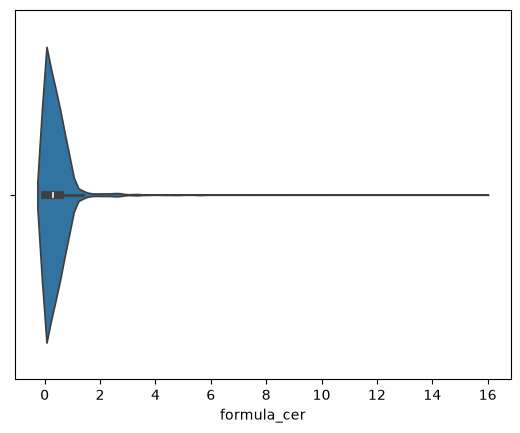

In [65]:
sns.violinplot(data=multimodal_rag_predictions, x="formula_cer")
plt.show()

In [66]:
multimodal_rag_predictions = multimodal_rag_predictions.sort_values(by='formula_cer', ascending=False)
multimodal_rag_predictions.head(n=20)

,prediction,reference,retrieved_ids,retrieved_targets,raw_asr,formula_cer,text_cer
2082,"Assume the pairs $z$, $n$ squared $\omega$ rai...",Assume to the contrary that $(N^2\omega)^{d-1}...,"[id_1357, id_304, id_2092]",[The case $e^{2\pi i \gamma} \neq \pm 1$ is si...,A sum to the power of d minus 1 does not equal 0.,15.760000,21.000000
1364,"...$ "" or ""The remaining coupling $c^2$ is sam...",The remaining coupling $C^2$ is same with that...,"[id_7527, id_1561, id_10317]","[In the case of minimal (no) coupling to $T$, ...",the remaining coupling c to the power of two i...,10.000000,0.961538
950,"Under this circumstance, the $\mathrm{PICK}$ m...","Under this circumstance, the PIC- $k$ method h...","[id_1947, id_2470, id_1422]","[In the next Section, we rely on this property...","Under this circumstance, the P-I-C-K method ha...",8.666667,0.039326
2752,The surface temperature is close to $900^\circ...,the surface temperature is close to nine hundr...,"[id_12307, id_7961, id_9891]","[and it was one hundred degrees outside, The a...",The surface temperature is close to 900 degree...,7.500000,0.340909
1118,"These VOAs, taking Equation as a definition, ...",These VOA's --- taking equation as a definitio...,"[id_8198, id_11242, id_8918]",[A $\operatorname{D} $-Lie algebra is an $A/k$...,"These VOAs, taken equation as a definition, we...",5.666667,0.076923
1123,"These FOAs, taking equation as a definition, w...",These VOA's --- taking equation as a definitio...,"[id_6292, id_2983, id_8143]",[Next we look at how to characterise various e...,"These FOAs, taking equation as a definition, w...",5.666667,0.088757
2805,of what civic hacking looks like i want to mak...,of what civic hacking looks like i want to mak...,"[id_13049, id_12876, id_12904]",[the good news i can share with you guys today...,of what civic hacking looks like. I want to ma...,5.500000,0.056075
258,"$..."" -> ""vertex set of $H-e$""? Or ""$H-e$""?",An $F$-tiling is perfect if it spans the verte...,"[id_10002, id_2926, id_11536]",[We choose a hyper-cubic Euclidean lattice wit...,An F-tiling is perfect if it spans the vertex ...,4.857143,0.909091
1262,$ or $T_3$ or $T_{\rm 3}$?\nIn LaTeX:,It was pointed out that the transition at $T_3...,"[id_108, id_1475, id_10708]",[We observe a sharp increase in that phaseshif...,it was pointed out that the transition at T su...,4.800000,0.942857
185,The situation will be satisfactory once there ...,The situation will be satisfactory once there ...,"[id_12867, id_4269, id_9869]",[allow for the mathematic possibilities of the...,The situation will be satisfactory once there ...,4.666667,0.014706


### Bootstrapping Formula CER

In [67]:
# 1. Create dummy data
np.random.seed(42)

def my_stat(data):
    return np.mean(data)

formula_cer_list = multimodal_rag_predictions.dropna()['formula_cer']
res = bootstrap((formula_cer_list,), my_stat, confidence_level=0.95, method='BCa', n_resamples=9999)
f"95% Confidence Interval: [{res.confidence_interval.low:.4f}, {res.confidence_interval.high:.4f}]"

'95% Confidence Interval: [0.3760, 0.4242]'

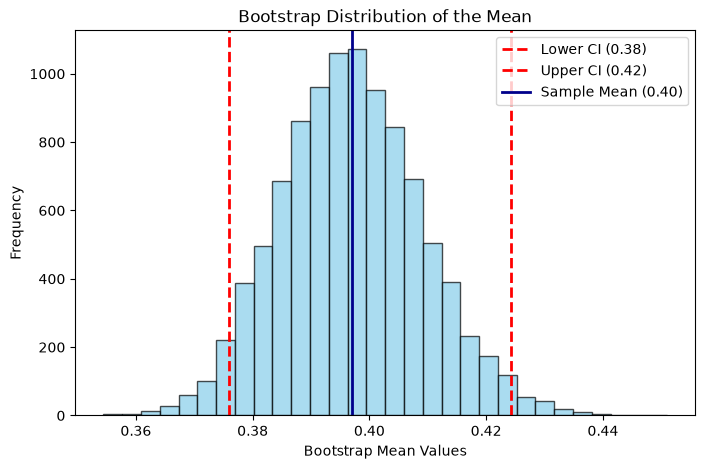

In [68]:
boot_dist = res.bootstrap_distribution
ci = res.confidence_interval

plt.figure(figsize=(8, 5))
plt.hist(boot_dist, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(ci.low, color='red', linestyle='--', linewidth=2, label=f'Lower CI ({ci.low:.2f})')
plt.axvline(ci.high, color='red', linestyle='--', linewidth=2, label=f'Upper CI ({ci.high:.2f})')
plt.axvline(np.mean(formula_cer_list), color='darkblue', linestyle='-', linewidth=2, label=f'Sample Mean ({np.mean(formula_cer_list):.2f})')

plt.title('Bootstrap Distribution of the Mean')
plt.xlabel('Bootstrap Mean Values')
plt.ylabel('Frequency')
plt.legend()
plt.show()


### Bootstrapping Text CER

In [69]:
# 1. Create dummy data
np.random.seed(42)

def my_stat(data):
    return np.mean(data)

text_cer_list = multimodal_rag_predictions.dropna()['text_cer']
res = bootstrap((text_cer_list,), my_stat, confidence_level=0.95, method='BCa', n_resamples=9999)
f"95% Confidence Interval: [{res.confidence_interval.low:.4f}, {res.confidence_interval.high:.4f}]"

'95% Confidence Interval: [0.1406, 0.1829]'

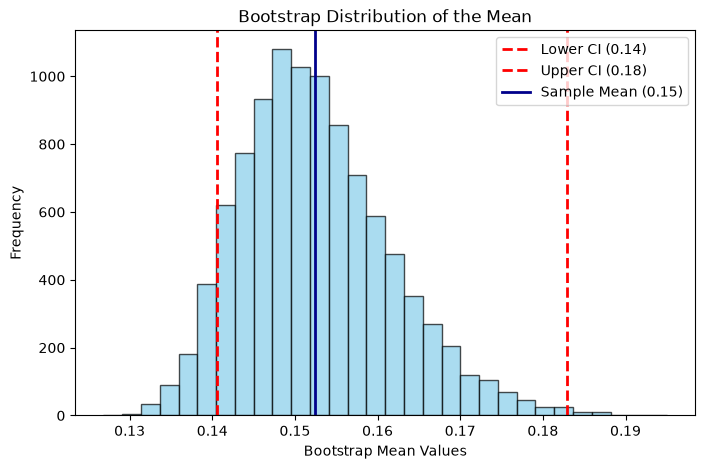

In [70]:
boot_dist = res.bootstrap_distribution
ci = res.confidence_interval

plt.figure(figsize=(8, 5))
plt.hist(boot_dist, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(ci.low, color='red', linestyle='--', linewidth=2, label=f'Lower CI ({ci.low:.2f})')
plt.axvline(ci.high, color='red', linestyle='--', linewidth=2, label=f'Upper CI ({ci.high:.2f})')
plt.axvline(np.mean(text_cer_list), color='darkblue', linestyle='-', linewidth=2, label=f'Sample Mean ({np.mean(text_cer_list):.2f})')

plt.title('Bootstrap Distribution of the Mean')
plt.xlabel('Bootstrap Mean Values')
plt.ylabel('Frequency')
plt.legend()
plt.show()


## Cross-condition comparison (formula/text CER)

Reuses `formula_text_cer` from above across every result directory in `results/`, so all conditions are on the same fast CER-only metric. Conditions share the exact same 2850-utterance reference order (verified by hashing the `reference` column across files), so they can be joined by row position.

- `raw_asr_whisper_large_v3`: the `raw_asr` column embedded in the RAG/post-correction runs — the actual backbone those methods correct, so this is the fairest "no correction" baseline for those comparisons.
- `whisper_small` / `whisper_medium`: standalone Whisper runs on a *different* backbone size — useful context, but not the same base transcription the RAG/post-correction methods operate on.
- `post_correction_*`: all three fine-tuned correction LLMs (Llama-3.2-1B-Instruct, Qwen2.5-1.5B-Instruct, Qwen3-1.7B).

In [71]:
CONDITIONS = {
    # name -> (path relative to results_directory, column holding the hypothesis text)
    "raw_asr_whisper_large_v3": ("multimodal_rag_no_retrieval/predictions_2026-09-25_22-40-18.jsonl", "raw_asr"),
    "whisper_small": ("whisper/predictions_2026-09-25_22-40-49.jsonl", "prediction"),
    "whisper_medium": ("whisper/predictions_2026-09-25_22-40-50.jsonl", "prediction"),
    "multimodal_rag": ("multimodal_rag/predictions.jsonl", "prediction"),
    "multimodal_rag_no_retrieval": ("multimodal_rag_no_retrieval/predictions_2026-09-25_22-40-18.jsonl", "prediction"),
    "multimodal_rag_whisper": ("multimodal_rag_whisper/predictions_2026-09-25_22-40-18.jsonl", "prediction"),
    "multimodal_rag_whisper_no_retrieval": (
        "multimodal_rag_whisper_no_retrieval/predictions_2026-09-26_11-54-50.jsonl",
        "prediction",
    ),
    "post_correction_llama3.2_1b": ("post_correction/predictions_2026-09-25_22-40-51.jsonl", "prediction"),
    "post_correction_qwen2.5_1.5b": ("post_correction/predictions_2026-09-25_22-42-54.jsonl", "prediction"),
    "post_correction_qwen3_1.7b": ("post_correction/predictions_2026-09-25_22-49-54.jsonl", "prediction"),
    "post_correction_rag": ("post_correction_rag/predictions_2026-09-26_11-54-50.jsonl", "prediction"),
    "post_correction_rag_no_retrieval": (
        "post_correction_rag_no_retrieval/predictions_2026-09-26_11-55-22.jsonl",
        "prediction",
    ),
}

all_records = []
for condition, (relative_path, column) in CONDITIONS.items():
    condition_predictions = pd.read_json(os.path.join(results_directory, relative_path), lines=True)
    for utterance_id, row in tqdm(
        condition_predictions.iterrows(),
        total=len(condition_predictions),
        desc=f"Computing CER: {condition}",
    ):
        row_metrics = formula_text_cer(row[column], row["reference"])
        row_metrics["condition"] = condition
        row_metrics["utterance_id"] = utterance_id
        all_records.append(row_metrics)

combined_cer = pd.DataFrame(all_records)
combined_cer.head()

Computing CER: multimodal_rag_whisper: 100%|██████████| 2850/2850 [00:12<00:00, 233.24it/s]
Computing CER: multimodal_rag_whisper_no_retrieval: 100%|██████████| 2850/2850 [00:12<00:00, 235.68it/s]
Computing CER: post_correction_rag_no_retrieval: 100%|██████████| 2850/2850 [00:12<00:00, 224.91it/s]


,formula_cer,text_cer,condition,utterance_id
0,0.939394,0.059459,raw_asr_whisper_large_v3,0
1,0.939394,0.102703,raw_asr_whisper_large_v3,1
2,0.939394,0.043243,raw_asr_whisper_large_v3,2
3,0.939394,0.081081,raw_asr_whisper_large_v3,3
4,0.939394,0.091892,raw_asr_whisper_large_v3,4


In [72]:
combined_cer.groupby("condition")[["formula_cer", "text_cer"]].agg(["mean", "median", "count"])

formula_cer                  text_cer  \
                                           mean    median count      mean   
condition                                                                   
multimodal_rag                         0.397000  0.285714  2735  0.146966   
multimodal_rag_no_retrieval            0.448560  0.368421  2740  0.231320   
multimodal_rag_whisper                 0.428360  0.333333  2737  0.224871   
multimodal_rag_whisper_no_retrieval    0.517423  0.461538  2737  0.369774   
post_correction_llama3.2_1b            0.477338  0.375000  2733  0.136691   
post_correction_qwen2.5_1.5b           0.808489  0.555556  2736  0.146960   
post_correction_qwen3_1.7b             0.390104  0.333333  2736  0.153378   
post_correction_rag                    0.426048  0.333333  2736  0.179607   
post_correction_rag_no_retrieval       0.471776  0.428571  2745  0.225731   
raw_asr_whisper_large_v3               0.842830  0.909091  2733  0.562144   
whisper_medium                         0.501283  0.361111  2736  0.128901   
whisper_small                          0.850077  0.909091  2733  0.528415   

                                                     
                                       median count  
condition                                            
multimodal_rag                       0.030303  2850  
multimodal_rag_no_retrieval          0.075000  2850  
multimodal_rag_whisper               0.049282  2850  
multimodal_rag_whisper_no_retrieval  0.128497  2850  
post_correction_llama3.2_1b          0.048465  2850  
post_correction_qwen2.5_1.5b         0.072007  2850  
post_correction_qwen3_1.7b           0.038462  2850  
post_correction_rag                  0.050000  2850  
post_correction_rag_no_retrieval     0.075758  2850  
raw_asr_whisper_large_v3             0.318958  2850  
whisper_medium                       0.044053  2850  
whisper_small                        0.288403  2850

### Bootstrap CIs across conditions

Same BCa bootstrap-of-the-mean approach used above for `multimodal_rag` alone, looped over every condition in `combined_cer`. The comparison plot for this is broken out by model family in the per-family comparisons section below, for the same reason the violin plots/Friedman test are: pooling all 12 conditions together isn't an apples-to-apples comparison.

In [73]:
def bootstrap_ci_by_condition(df, metric, n_resamples=9999):
    results = []
    distributions = {}
    for condition, group in df.groupby("condition"):
        data = group[metric].dropna().to_numpy()
        res = bootstrap(
            (data,), np.mean, confidence_level=0.95, method="BCa", n_resamples=n_resamples
        )
        results.append(
            {
                "condition": condition,
                "metric": metric,
                "mean": np.mean(data),
                "ci_low": res.confidence_interval.low,
                "ci_high": res.confidence_interval.high,
                "n": len(data),
            }
        )
        distributions[condition] = res.bootstrap_distribution
    return pd.DataFrame(results), distributions


condition_ci_formula, boot_dist_formula = bootstrap_ci_by_condition(combined_cer, "formula_cer")
condition_ci_text, boot_dist_text = bootstrap_ci_by_condition(combined_cer, "text_cer")

condition_ci = pd.concat([condition_ci_formula, condition_ci_text], ignore_index=True)
boot_distributions = {"formula_cer": boot_dist_formula, "text_cer": boot_dist_text}

condition_ci.sort_values(["metric", "mean"])

,condition,metric,mean,ci_low,ci_high,n
6,post_correction_qwen3_1.7b,formula_cer,0.390104,0.371487,0.419766,2736
0,multimodal_rag,formula_cer,0.397000,0.375846,0.424506,2735
7,post_correction_rag,formula_cer,0.426048,0.404625,0.457838,2736
2,multimodal_rag_whisper,formula_cer,0.428360,0.409820,0.455773,2737
1,multimodal_rag_no_retrieval,formula_cer,0.448560,0.427738,0.477485,2740
8,post_correction_rag_no_retrieval,formula_cer,0.471776,0.452103,0.508207,2745
4,post_correction_llama3.2_1b,formula_cer,0.477338,0.448099,0.526299,2733
10,whisper_medium,formula_cer,0.501283,0.466377,0.547215,2736
3,multimodal_rag_whisper_no_retrieval,formula_cer,0.517423,0.494081,0.556200,2737
5,post_correction_qwen2.5_1.5b,formula_cer,0.808489,0.768030,0.857629,2736


### Per-condition distributions: describe()

In [74]:
combined_cer.groupby("condition")[["formula_cer", "text_cer"]].describe()

formula_cer                                \
                                          count      mean       std       min   
condition                                                                       
multimodal_rag                           2735.0  0.397000  0.639093  0.000000   
multimodal_rag_no_retrieval              2740.0  0.448560  0.651159  0.000000   
multimodal_rag_whisper                   2737.0  0.428360  0.588273  0.000000   
multimodal_rag_whisper_no_retrieval      2737.0  0.517423  0.804300  0.000000   
post_correction_llama3.2_1b              2733.0  0.477338  0.993717  0.000000   
post_correction_qwen2.5_1.5b             2736.0  0.808489  1.182983  0.000000   
post_correction_qwen3_1.7b               2736.0  0.390104  0.606230  0.000000   
post_correction_rag                      2736.0  0.426048  0.696171  0.000000   
post_correction_rag_no_retrieval         2745.0  0.471776  0.692404  0.000000   
raw_asr_whisper_large_v3                 2733.0  0.842830  0.168747  0.333333   
whisper_medium                           2736.0  0.501283  1.067319  0.000000   
whisper_small                            2733.0  0.850077  0.354449  0.333333   

                                                                              \
                                          25%       50%       75%        max   
condition                                                                      
multimodal_rag                       0.000000  0.285714  0.564427  15.760000   
multimodal_rag_no_retrieval          0.095238  0.368421  0.666667  16.500000   
multimodal_rag_whisper               0.067568  0.333333  0.652174  19.500000   
multimodal_rag_whisper_no_retrieval  0.148148  0.461538  0.779310  24.000000   
post_correction_llama3.2_1b          0.115385  0.375000  0.625000  28.472222   
post_correction_qwen2.5_1.5b         0.263903  0.555556  0.877551  20.500000   
post_correction_qwen3_1.7b           0.045455  0.333333  0.568966  19.472727   
post_correction_rag                  0.043025  0.333333  0.666667  18.500000   
post_correction_rag_no_retrieval     0.100000  0.428571  0.715596  27.000000   
raw_asr_whisper_large_v3             0.818182  0.909091  0.942857   0.986207   
whisper_medium                       0.095238  0.361111  0.604804  24.090909   
whisper_small                        0.818182  0.909091  0.944444  16.894737   

                                    text_cer                           \
                                       count      mean       std  min   
condition                                                               
multimodal_rag                        2850.0  0.146966  0.465731  0.0   
multimodal_rag_no_retrieval           2850.0  0.231320  0.584099  0.0   
multimodal_rag_whisper                2850.0  0.224871  0.396609  0.0   
multimodal_rag_whisper_no_retrieval   2850.0  0.369774  0.479997  0.0   
post_correction_llama3.2_1b           2850.0  0.136691  0.383483  0.0   
post_correction_qwen2.5_1.5b          2850.0  0.146960  0.213496  0.0   
post_correction_qwen3_1.7b            2850.0  0.153378  1.282635  0.0   
post_correction_rag                   2850.0  0.179607  0.255090  0.0   
post_correction_rag_no_retrieval      2850.0  0.225731  0.292362  0.0   
raw_asr_whisper_large_v3              2850.0  0.562144  0.692864  0.0   
whisper_medium                        2850.0  0.128901  0.326827  0.0   
whisper_small                         2850.0  0.528415  0.793559  0.0   

                                                                              
                                          25%       50%       75%        max  
condition                                                                     
multimodal_rag                       0.007273  0.030303  0.145103  21.000000  
multimodal_rag_no_retrieval          0.017131  0.075000  0.301587  24.672727  
multimodal_rag_whisper               0.013245  0.049282  0.232078   9.140351  
multimodal_rag_whisper_no_retrieval  0.028829  0.

## Per-family comparisons: bootstrap CIs, violin plots, Friedman test, post-hoc

Pooling all 12 conditions into a single repeated-measures test (or a single CI comparison plot) mixes different Whisper backbones and objectives together, which isn't a fair comparison. Instead, the conditions are split into the four model families they naturally fall into, and each family gets its own within-family comparison -- bootstrap CI plot, violin plot, Friedman test, Holm-corrected pairwise Wilcoxon signed-rank (the latter two on `formula_cer`, complete-case utterances):

- **Finetuned ASR** -- `raw_asr_whisper_large_v3`, `whisper_small`, `whisper_medium`
- **Finetuned post-correction** -- `post_correction_llama3.2_1b`, `post_correction_qwen2.5_1.5b`, `post_correction_qwen3_1.7b`
- **Post-correction RAG** -- `post_correction_rag`, `post_correction_rag_no_retrieval`
- **Multimodal RAG** -- `multimodal_rag`, `multimodal_rag_no_retrieval`, `multimodal_rag_whisper`, `multimodal_rag_whisper_no_retrieval`

In [75]:
import scipy.stats as stats
from itertools import combinations

def violin_plot_for_conditions(df, conditions, figsize_height=6):
    subset = df[df["condition"].isin(conditions)]
    order = subset.groupby("condition")["formula_cer"].mean().sort_values().index

    fig, axes = plt.subplots(1, 2, figsize=(16, figsize_height))
    for ax, metric in zip(axes, ["formula_cer", "text_cer"]):
        sns.violinplot(data=subset, x=metric, y="condition", order=order, ax=ax, cut=0)
        ax.set_xlim(0, 2)
        ax.set_title(metric)
    plt.tight_layout()
    plt.show()


def friedman_test_for_conditions(df, conditions, metric="formula_cer"):
    wide = df[df["condition"].isin(conditions)].pivot(index="utterance_id", columns="condition", values=metric)
    wide_complete = wide.dropna()
    print(f"utterances: {len(wide_complete)} complete cases / {len(wide)} total")

    statistic, p_value = stats.friedmanchisquare(*[wide_complete[c] for c in wide_complete.columns])
    print(f"Friedman chi2: {statistic:.4f}")
    print(f"P-value: {p_value:.8g}")
    return wide_complete


def posthoc_wilcoxon_holm(wide_complete):
    conditions = wide_complete.columns.tolist()

    posthoc_records = []
    for condition_a, condition_b in combinations(conditions, 2):
        w_statistic, w_p_value = stats.wilcoxon(wide_complete[condition_a], wide_complete[condition_b])
        posthoc_records.append(
            {
                "condition_a": condition_a,
                "condition_b": condition_b,
                "statistic": w_statistic,
                "p_value": w_p_value,
            }
        )

    posthoc = pd.DataFrame(posthoc_records).sort_values("p_value").reset_index(drop=True)

    # Holm step-down correction: adjusted_p[i] = max(adjusted_p[i-1], (m - i) * p[i]), clipped to 1.0
    n_comparisons = len(posthoc)
    p_holm = np.empty(n_comparisons)
    running_max = 0.0
    for i, p in enumerate(posthoc["p_value"].to_numpy()):
        running_max = max(running_max, (n_comparisons - i) * p)
        p_holm[i] = min(running_max, 1.0)

    posthoc["p_holm"] = p_holm
    posthoc["significant_0.05"] = posthoc["p_holm"] < 0.05

    print(f"{posthoc['significant_0.05'].sum()} / {n_comparisons} pairwise comparisons significant at alpha=0.05 (Holm-corrected)")
    return posthoc


def plot_bootstrap_distributions_for_conditions(boot_distributions, condition_ci, conditions, subplot_height=3):
    fig, axes = plt.subplots(len(conditions), 2, figsize=(14, subplot_height * len(conditions)), squeeze=False)

    for row, condition in enumerate(conditions):
        for col, metric in enumerate(["formula_cer", "text_cer"]):
            boot_dist = boot_distributions[metric][condition]
            ci_row = condition_ci[
                (condition_ci["condition"] == condition) & (condition_ci["metric"] == metric)
            ].iloc[0]

            ax = axes[row][col]
            ax.hist(boot_dist, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
            ax.axvline(ci_row["ci_low"], color="red", linestyle="--", linewidth=2, label=f"Lower CI ({ci_row['ci_low']:.3f})")
            ax.axvline(ci_row["ci_high"], color="red", linestyle="--", linewidth=2, label=f"Upper CI ({ci_row['ci_high']:.3f})")
            ax.axvline(ci_row["mean"], color="darkblue", linestyle="-", linewidth=2, label=f"Mean ({ci_row['mean']:.3f})")
            ax.set_title(f"{condition} -- {metric}")
            ax.set_xlabel("Bootstrap mean")
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Finetuned ASR

Standalone Whisper backbones, no LLM correction: `raw_asr_whisper_large_v3`, `whisper_small`, `whisper_medium`.

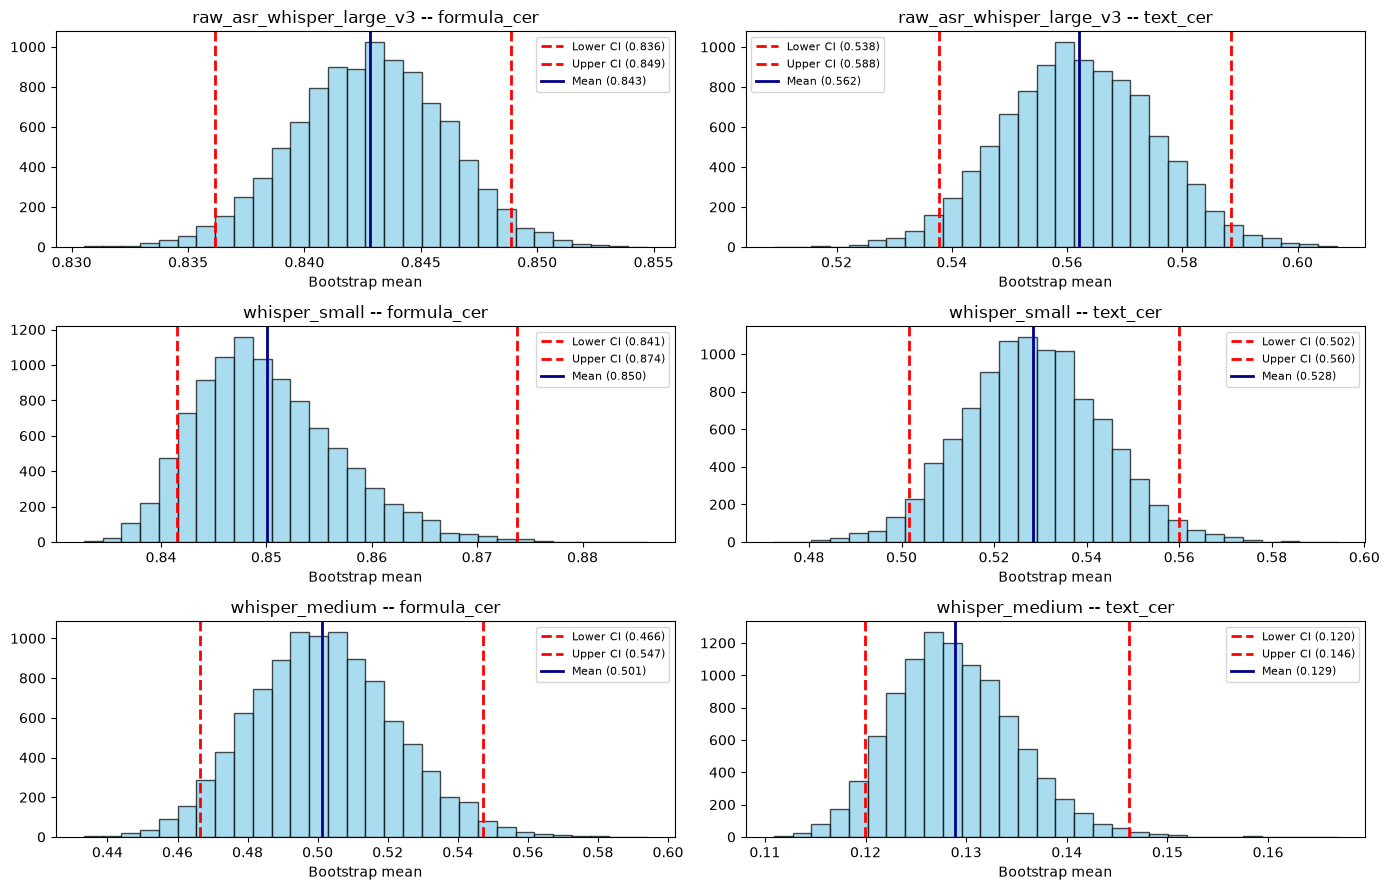

In [76]:
FINETUNED_ASR = ["raw_asr_whisper_large_v3", "whisper_small", "whisper_medium"]
plot_bootstrap_distributions_for_conditions(boot_distributions, condition_ci, FINETUNED_ASR)

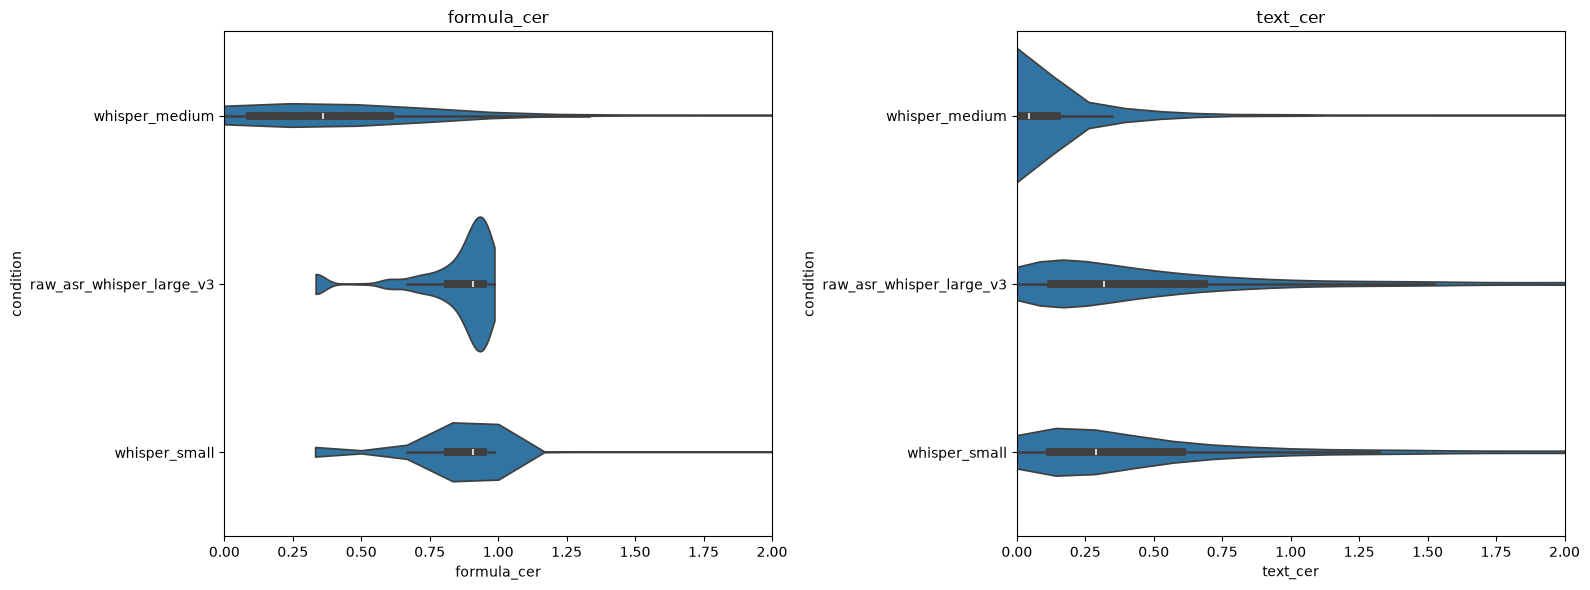

In [77]:
violin_plot_for_conditions(combined_cer, FINETUNED_ASR)

In [78]:
finetuned_asr_wide = friedman_test_for_conditions(combined_cer, FINETUNED_ASR)

utterances: 2733 complete cases / 2850 total
Friedman chi2: 3762.5353
P-value: 0


In [79]:
posthoc_wilcoxon_holm(finetuned_asr_wide)

2 / 3 pairwise comparisons significant at alpha=0.05 (Holm-corrected)


,condition_a,condition_b,statistic,p_value,p_holm,significant_0.05
0,whisper_medium,whisper_small,363053.5,6.393913e-276,1.918174e-275,True
1,raw_asr_whisper_large_v3,whisper_medium,363351.5,8.353493e-276,1.918174e-275,True
2,raw_asr_whisper_large_v3,whisper_small,0.0,1.088094e-01,1.088094e-01,False


### Finetuned post-correction

Whisper-large-v3 raw ASR corrected by a fine-tuned LLM, no retrieval: `post_correction_llama3.2_1b`, `post_correction_qwen2.5_1.5b`, `post_correction_qwen3_1.7b`.

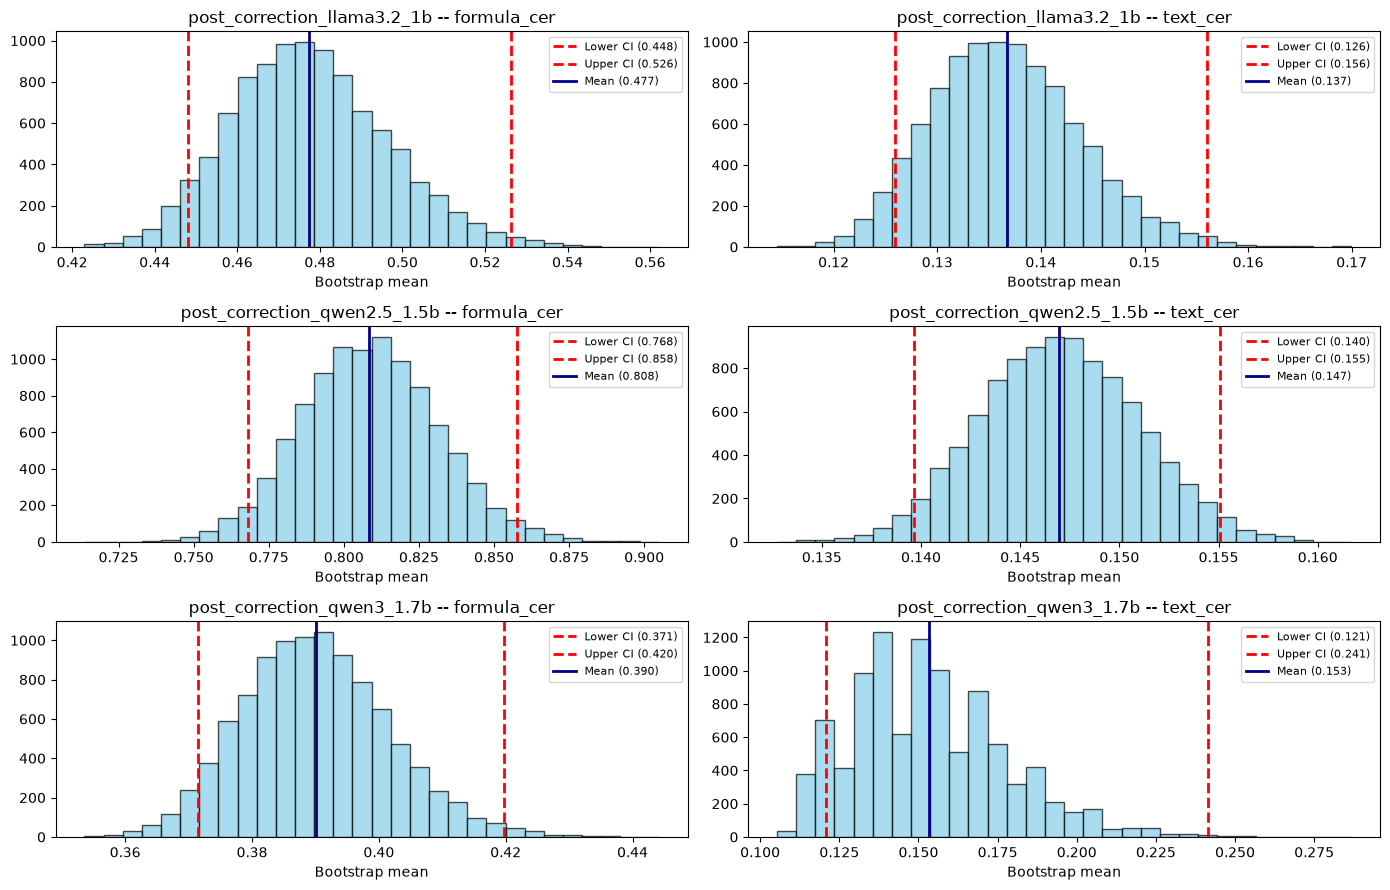

In [80]:
FINETUNED_POST_CORRECTION = [
    "post_correction_llama3.2_1b",
    "post_correction_qwen2.5_1.5b",
    "post_correction_qwen3_1.7b",
]
plot_bootstrap_distributions_for_conditions(boot_distributions, condition_ci, FINETUNED_POST_CORRECTION)

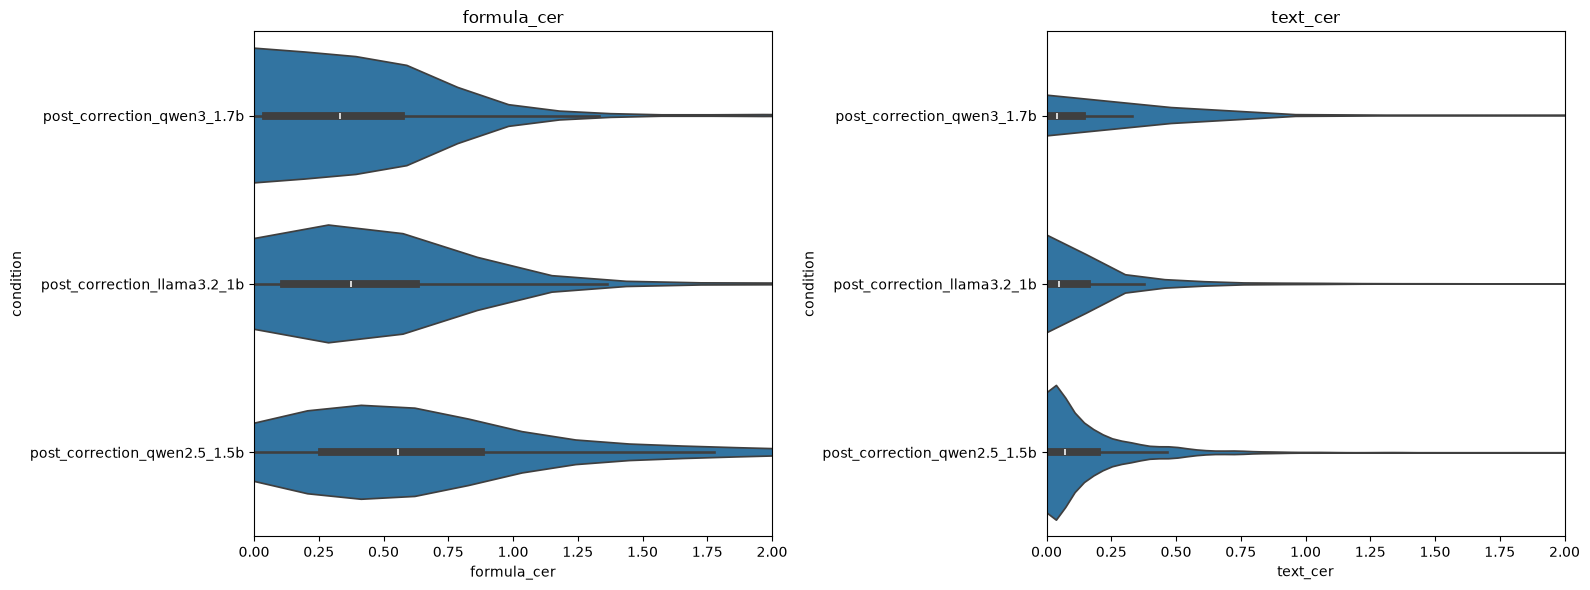

In [81]:
violin_plot_for_conditions(combined_cer, FINETUNED_POST_CORRECTION)

In [82]:
finetuned_post_correction_wide = friedman_test_for_conditions(combined_cer, FINETUNED_POST_CORRECTION)

utterances: 2733 complete cases / 2850 total
Friedman chi2: 678.2942
P-value: 5.1319755e-148


In [83]:
posthoc_wilcoxon_holm(finetuned_post_correction_wide)

3 / 3 pairwise comparisons significant at alpha=0.05 (Holm-corrected)


,condition_a,condition_b,statistic,p_value,p_holm,significant_0.05
0,post_correction_qwen2.5_1.5b,post_correction_qwen3_1.7b,364700.5,1.192562e-144,3.577686e-144,True
1,post_correction_llama3.2_1b,post_correction_qwen2.5_1.5b,546469.5,1.998473e-89,3.996947e-89,True
2,post_correction_llama3.2_1b,post_correction_qwen3_1.7b,439888.0,1.771642e-26,1.771642e-26,True


### Post-correction RAG

Whisper-large-v3 raw ASR corrected by a fine-tuned LLM with retrieval, plus a no-retrieval ablation: `post_correction_rag`, `post_correction_rag_no_retrieval`.

Only two conditions here, so Friedman (which needs at least 3 repeated measures) doesn't apply -- this goes straight to a single paired Wilcoxon signed-rank test on the complete-case utterances.

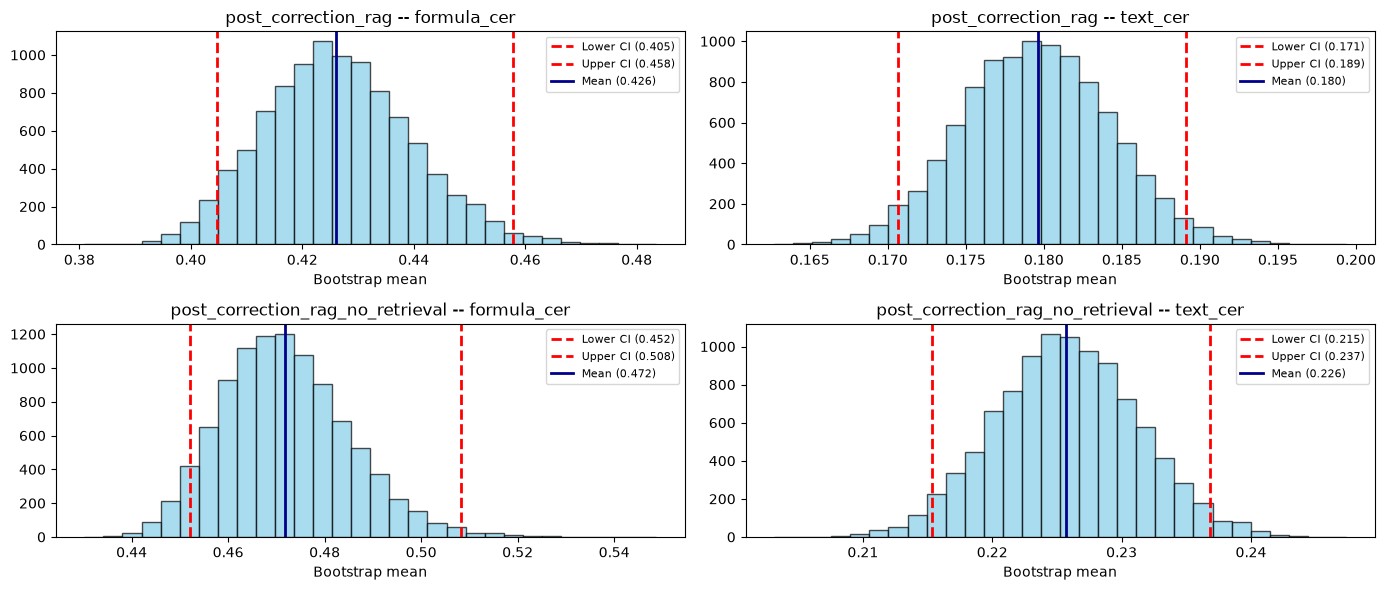

In [84]:
POST_CORRECTION_RAG = ["post_correction_rag", "post_correction_rag_no_retrieval"]
plot_bootstrap_distributions_for_conditions(boot_distributions, condition_ci, POST_CORRECTION_RAG, subplot_height=3)

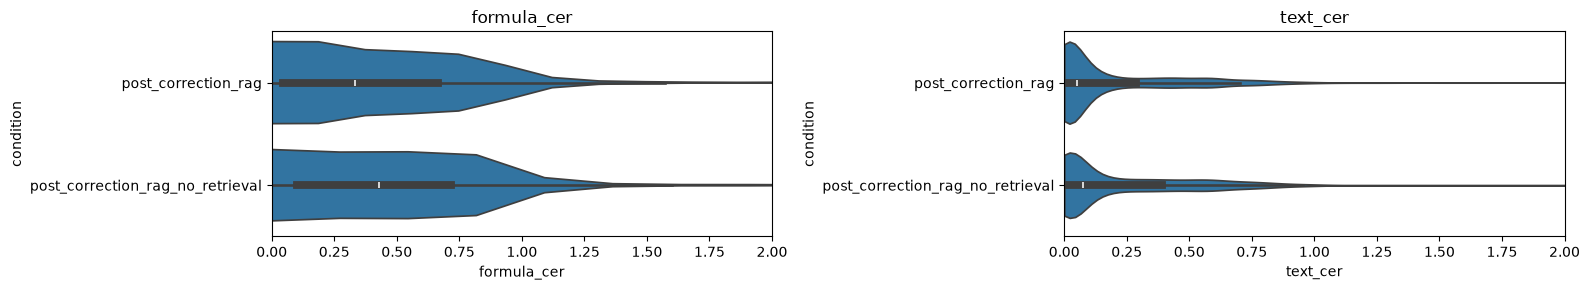

In [85]:
violin_plot_for_conditions(combined_cer, POST_CORRECTION_RAG, figsize_height=3)

In [86]:
post_correction_rag_wide = (
    combined_cer[combined_cer["condition"].isin(POST_CORRECTION_RAG)]
    .pivot(index="utterance_id", columns="condition", values="formula_cer")
    .dropna()
)
print(f"utterances: {len(post_correction_rag_wide)} complete cases")

statistic, p_value = stats.wilcoxon(
    post_correction_rag_wide[POST_CORRECTION_RAG[0]], post_correction_rag_wide[POST_CORRECTION_RAG[1]]
)
print(f"Wilcoxon statistic: {statistic:.4f}")
print(f"P-value: {p_value:.8g}")

utterances: 2736 complete cases
Wilcoxon statistic: 353823.0000
P-value: 1.8480662e-18


### Multimodal RAG

RAG over the multimodal (image + text) representation, with a retrieval ablation and a Whisper-backbone-vs-multimodal-encoder ablation: `multimodal_rag`, `multimodal_rag_no_retrieval`, `multimodal_rag_whisper`, `multimodal_rag_whisper_no_retrieval`.

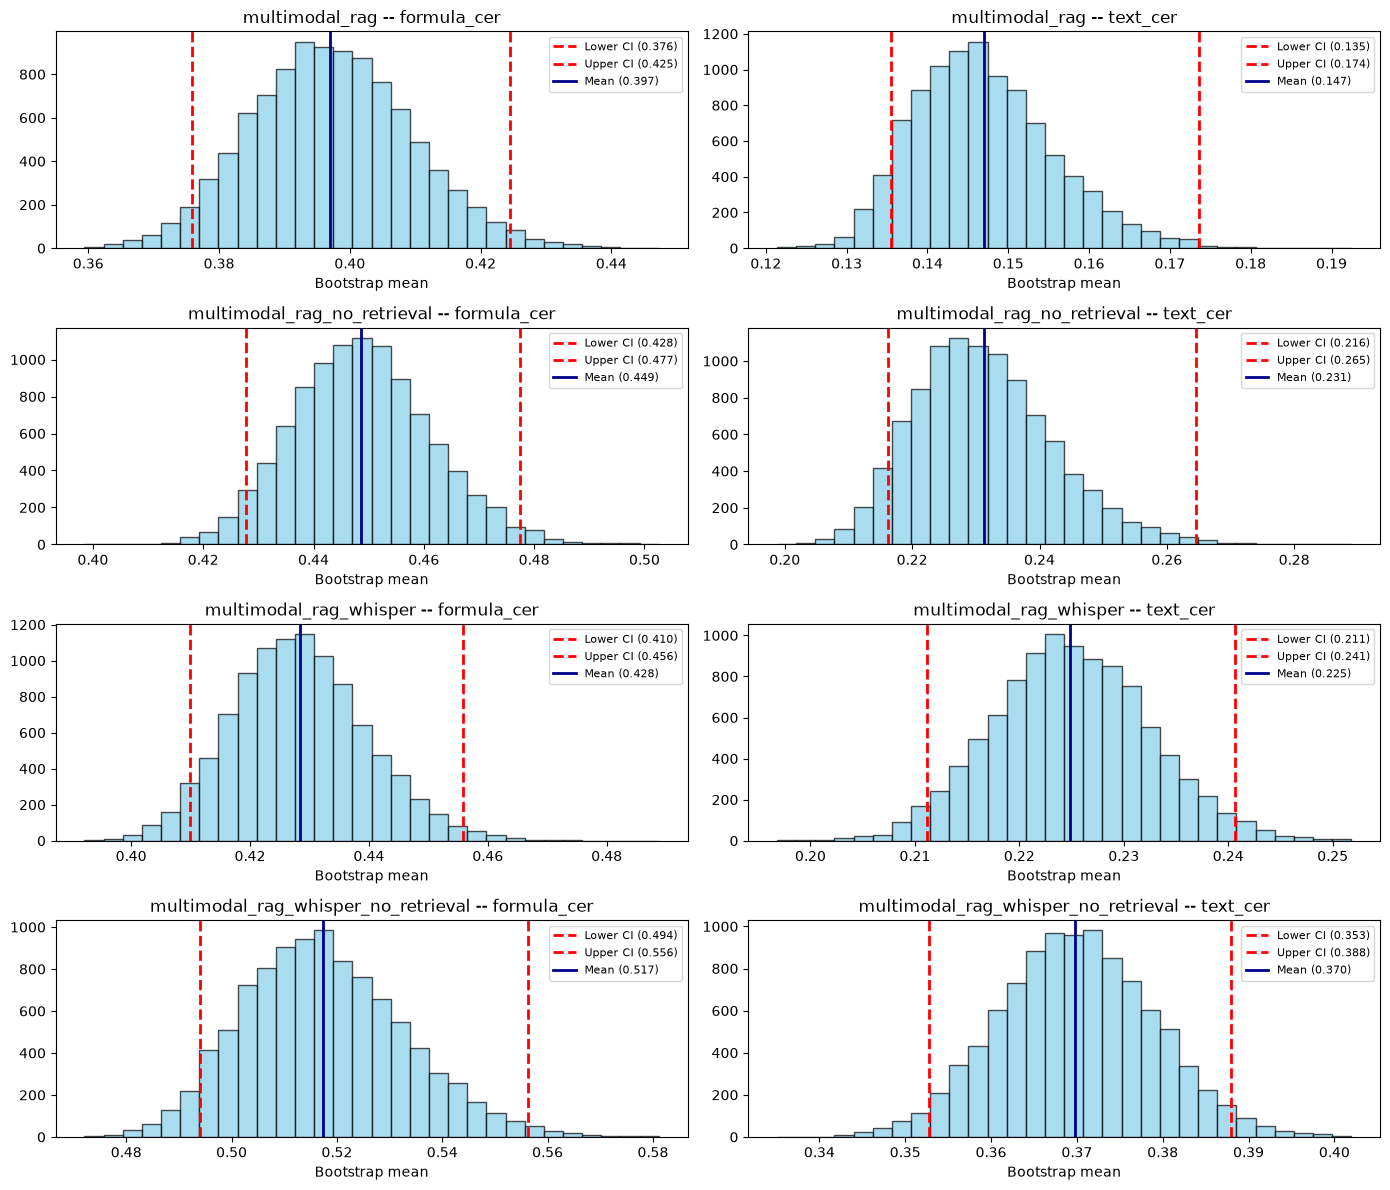

In [87]:
MULTIMODAL_RAG = [
    "multimodal_rag",
    "multimodal_rag_no_retrieval",
    "multimodal_rag_whisper",
    "multimodal_rag_whisper_no_retrieval",
]
plot_bootstrap_distributions_for_conditions(boot_distributions, condition_ci, MULTIMODAL_RAG)

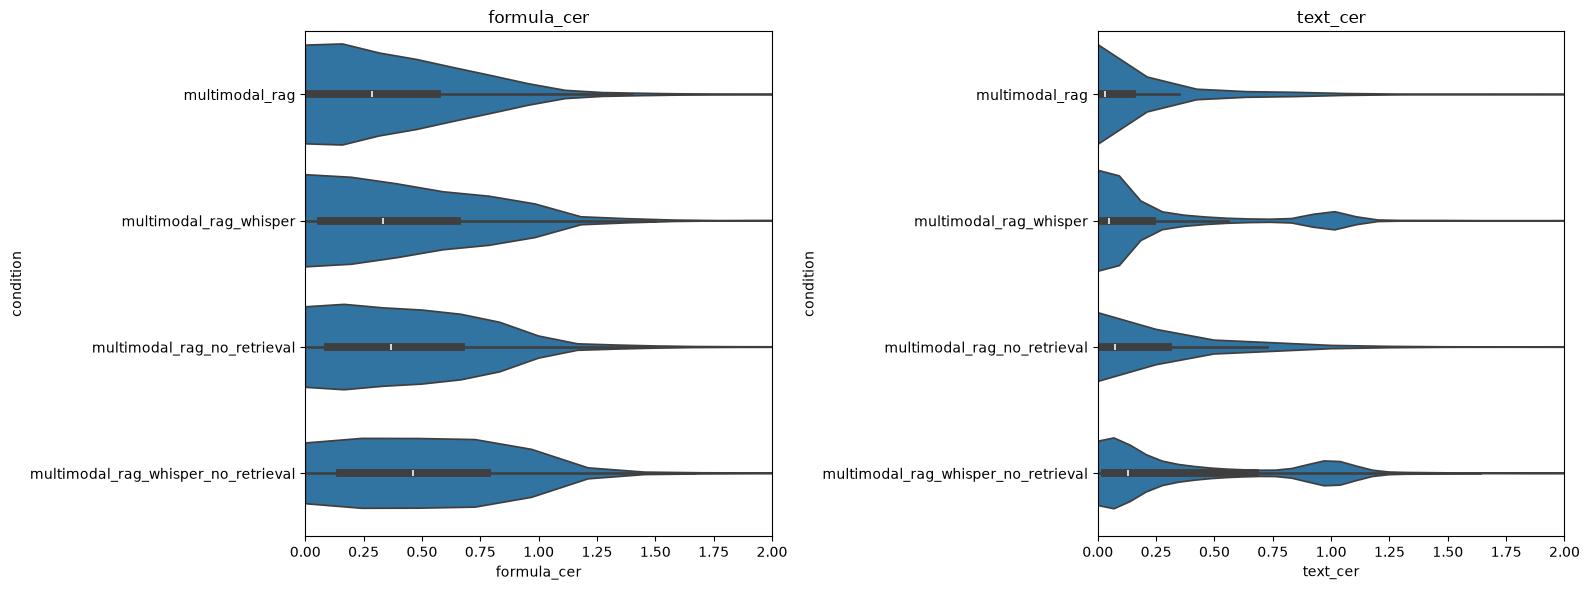

In [88]:
violin_plot_for_conditions(combined_cer, MULTIMODAL_RAG)

In [89]:
multimodal_rag_wide = friedman_test_for_conditions(combined_cer, MULTIMODAL_RAG)

utterances: 2734 complete cases / 2850 total
Friedman chi2: 402.3053
P-value: 7.0114136e-87


In [90]:
posthoc_wilcoxon_holm(multimodal_rag_wide)

6 / 6 pairwise comparisons significant at alpha=0.05 (Holm-corrected)


,condition_a,condition_b,statistic,p_value,p_holm,significant_0.05
0,multimodal_rag,multimodal_rag_whisper_no_retrieval,435166.5,3.644830e-76,2.186898e-75,True
1,multimodal_rag_whisper,multimodal_rag_whisper_no_retrieval,400845.0,1.004767e-40,5.023837e-40,True
2,multimodal_rag_no_retrieval,multimodal_rag_whisper_no_retrieval,447618.0,3.134514e-29,1.253806e-28,True
3,multimodal_rag,multimodal_rag_no_retrieval,434989.5,1.405798e-27,4.217393e-27,True
4,multimodal_rag,multimodal_rag_whisper,612788.5,1.126884e-13,2.253768e-13,True
5,multimodal_rag_no_retrieval,multimodal_rag_whisper,687850.5,2.414011e-02,2.414011e-02,True
